<a href="https://colab.research.google.com/github/aryaveermajumdar/fsfm-based-neutral-face-project/blob/main/FSFM_Emotion_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, sys, torch
import torchvision.transforms as T
from PIL import Image
from torch.utils.data import Dataset, DataLoader, TensorDataset
from collections import Counter
from google.colab import drive

drive.mount('/content/drive')

print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

DRIVE_BASE    = '/content/drive/MyDrive/Colab Notebooks'
RAFDB_BASE    = f'{DRIVE_BASE}/RAF-DB/basic'
RAFDB_CACHE   = f'{DRIVE_BASE}/RAF-DB'

MEAN = [0.5482207536697388, 0.42340534925460815, 0.3654651641845703]
STD  = [0.2789176106452942, 0.2438540756702423,  0.23493893444538116]
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD)
])

RAFDB_CLASSES = ['Surprise','Fear','Disgust',
                 'Happiness','Sadness','Anger','Neutral']
RACE_MAP      = {0: 'White/Middle Eastern', 1: 'Black', 2: 'Asian'}
GENDER_MAP    = {0: 'Male', 1: 'Female', 2: 'Unsure'}
AGE_MAP       = {0: 'Young', 1: 'Middle', 2: 'Old'}

AGE_TO_3CLASS = {0:0, 1:0, 2:0, 3:1, 4:1, 5:1, 6:2, 7:2, 8:2}

print("Setup complete.")

Mounted at /content/drive
CUDA: True
GPU: Tesla T4
Setup complete.


In [2]:
!git clone https://github.com/wolo-wolo/FSFM-CVPR25.git
!pip install timm einops huggingface_hub --quiet

Cloning into 'FSFM-CVPR25'...
remote: Enumerating objects: 340, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 340 (delta 28), reused 6 (delta 6), pack-reused 292 (from 1)
Receiving objects: 100% (340/340), 51.37 MiB | 26.88 MiB/s, done.
Resolving deltas: 100% (181/181), done.


In [3]:
from huggingface_hub import hf_hub_download

os.makedirs('/content/fsfm_checkpoints', exist_ok=True)
hf_hub_download(
    repo_id="Wolowolo/fsfm-3c",
    filename="pretrained_models/VF2_ViT-B/checkpoint-400.pth",
    local_dir="/content/fsfm_checkpoints/",
    local_dir_use_symlinks=False,
    resume_download=True
)
print("Checkpoint ready.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `hf_hub_download`. Downloads always resume whenever possible.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  w

pretrained_models/VF2_ViT-B/checkpoint-4(…):   0%|          | 0.00/1.60G [00:00<?, ?B/s]

Checkpoint ready.


In [4]:
sys.path.insert(0, '/content/FSFM-CVPR25/fsfm-3c/finuetune/cross_domain_FAS')
import models_vit

backbone = models_vit.vit_base_patch16(
    num_classes=0, drop_path_rate=0.0, global_pool=False
)
checkpoint = torch.load(
    '/content/fsfm_checkpoints/pretrained_models/VF2_ViT-B/checkpoint-400.pth',
    map_location='cpu', weights_only=False
)
backbone.load_state_dict(checkpoint['model'], strict=False)
backbone = backbone.cuda().eval()

dummy = torch.randn(2, 3, 224, 224).cuda()
with torch.no_grad():
    out = backbone.forward_features(dummy)[:, 0, :]
print("Backbone ready. CLS shape:", out.shape)

/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Backbone ready. CLS shape: torch.Size([2, 768])


In [5]:
def parse_rafdb_labels(label_file):
    samples = []
    with open(label_file) as f:
        for line in f:
            parts = line.strip().split()
            samples.append((parts[0], int(parts[1]) - 1))
    return samples

class RAFDBDataset(Dataset):
    def __init__(self, split, base_path, transform=None):
        self.img_dir   = os.path.join(base_path, 'Image', 'aligned')
        self.anno_dir  = os.path.join(base_path, 'Annotation', 'manual')
        self.transform = transform
        self.split     = split
        self.samples   = []

        label_file = os.path.join(base_path, 'EmoLabel',
                                  'list_partition_label.txt')
        with open(label_file) as f:
            for line in f:
                parts  = line.strip().split()
                fname  = parts[0]
                label  = int(parts[1]) - 1
                if not fname.startswith(split):
                    continue
                prefix, num_str = fname.replace('.jpg','').rsplit('_', 1)
                num = int(num_str)
                if split == 'train':
                    aligned_name = f'{prefix}_{num:05d}_aligned.jpg'
                    anno_name    = f'{prefix}_{num:05d}_manu_attri.txt'
                else:
                    aligned_name = f'{prefix}_{num:04d}_aligned.jpg'
                    anno_name    = f'{prefix}_{num:04d}_manu_attri.txt'

                img_path  = os.path.join(self.img_dir, aligned_name)
                anno_path = os.path.join(self.anno_dir, anno_name)
                if not os.path.exists(img_path) or \
                   not os.path.exists(anno_path):
                    continue

                with open(anno_path) as af:
                    lines = af.read().strip().split('\n')
                gender = int(lines[-3].strip())
                race   = int(lines[-2].strip())
                age    = int(lines[-1].strip())

                self.samples.append((img_path, label, race, gender, age))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, race, gender, age = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label, race, gender, age

train_ds = RAFDBDataset('train', RAFDB_BASE, transform)
test_ds  = RAFDBDataset('test',  RAFDB_BASE, transform)
print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")

Train: 252 | Test: 64


In [6]:
import numpy as np
import torch.nn as nn
import torch.optim as optim

train_cache = torch.load(f'{RAFDB_CACHE}/train_features.pt',
                          weights_only=False)
test_cache  = torch.load(f'{RAFDB_CACHE}/test_features.pt',
                          weights_only=False)

train_cache['genders'] = train_cache['genders'].clamp(0, 1)
test_cache['genders']  = test_cache['genders'].clamp(0, 1)

train_loader = DataLoader(
    TensorDataset(train_cache['features'], train_cache['labels'],
                  train_cache['races']),
    batch_size=256, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(test_cache['features'], test_cache['labels'],
                  test_cache['races']),
    batch_size=256, shuffle=False
)
print("Caches loaded.")
print("Train:", train_cache['features'].shape)
print("Test: ", test_cache['features'].shape)

Caches loaded.
Train: torch.Size([12271, 768])
Test:  torch.Size([3068, 768])


In [7]:
head = nn.Sequential(
    nn.Linear(768, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(0.3),
    nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.3),
    nn.Linear(256, 7)
).cuda()

counts  = Counter(train_cache['labels'].tolist())
total_n = sum(counts.values())
weights = torch.tensor([total_n/counts[i] for i in range(7)],
                        dtype=torch.float).cuda()
weights = weights / weights.sum()
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.AdamW(head.parameters(), lr=1e-3, weight_decay=0.05)

for epoch in range(20):
    head.train()
    correct, total = 0, 0
    for feats, labels, _ in train_loader:
        feats, labels = feats.cuda(), labels.cuda()
        logits = head(feats)
        loss   = criterion(logits, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        correct += (logits.argmax(1) == labels).sum().item()
        total   += labels.size(0)

    head.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for feats, labels, _ in test_loader:
            feats, labels = feats.cuda(), labels.cuda()
            logits = head(feats)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    print(f"Epoch {epoch+1:02d}/20 | "
          f"Train: {correct/total:.3f} | Val: {val_correct/val_total:.3f}")

Epoch 01/20 | Train: 0.584 | Val: 0.734
Epoch 02/20 | Train: 0.766 | Val: 0.777
Epoch 03/20 | Train: 0.810 | Val: 0.776
Epoch 04/20 | Train: 0.835 | Val: 0.821
Epoch 05/20 | Train: 0.855 | Val: 0.827
Epoch 06/20 | Train: 0.878 | Val: 0.809
Epoch 07/20 | Train: 0.890 | Val: 0.794
Epoch 08/20 | Train: 0.905 | Val: 0.803
Epoch 09/20 | Train: 0.912 | Val: 0.828
Epoch 10/20 | Train: 0.920 | Val: 0.826
Epoch 11/20 | Train: 0.931 | Val: 0.825
Epoch 12/20 | Train: 0.936 | Val: 0.832
Epoch 13/20 | Train: 0.935 | Val: 0.812
Epoch 14/20 | Train: 0.939 | Val: 0.838
Epoch 15/20 | Train: 0.944 | Val: 0.827
Epoch 16/20 | Train: 0.947 | Val: 0.819
Epoch 17/20 | Train: 0.947 | Val: 0.806
Epoch 18/20 | Train: 0.943 | Val: 0.815
Epoch 19/20 | Train: 0.949 | Val: 0.820
Epoch 20/20 | Train: 0.959 | Val: 0.830


In [8]:
import torch
import numpy as np

def get_attention_map(backbone, img_tensor):
    backbone.eval()

    # Disable fused attention on all blocks so we can hook the weights
    for block in backbone.blocks:
        block.attn.fused_attn = False

    attn_maps = []

    def hook_fn(module, input, output):
        attn_maps.append(output.detach().cpu())

    hooks = []
    for block in backbone.blocks:
        hooks.append(block.attn.attn_drop.register_forward_hook(hook_fn))

    with torch.no_grad():
        _ = backbone.forward_features(img_tensor.unsqueeze(0).cuda())

    for h in hooks:
        h.remove()

    # Re-enable fused attention
    for block in backbone.blocks:
        block.attn.fused_attn = True

    # Last layer, average over heads, CLS→patches
    last_attn = attn_maps[-1]          # (1, heads, 197, 197)
    print("Raw attention shape:", last_attn.shape)
    cls_attn  = last_attn[0, :, 0, 1:]  # (heads, 196)
    cls_attn  = cls_attn.mean(0)         # (196,)
    cls_attn  = cls_attn.reshape(14, 14) # 14x14

    return cls_attn

img, label, race, gender, age = test_ds[0]
attn = get_attention_map(backbone, img)
print("Attention map shape:", attn.shape)
print("Min:", attn.min().item(), "Max:", attn.max().item())

Raw attention shape: torch.Size([1, 12, 197, 197])
Attention map shape: torch.Size([14, 14])
Min: 0.0008466045837849379 Max: 0.023859428241848946


In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F

def visualize_attention(img_tensor, attn_map, original_img, title, ax):
    """Overlay attention map on original face image."""
    # Normalize attention
    attn = attn_map.numpy()
    attn = (attn - attn.min()) / (attn.max() - attn.min())

    # Upsample to 224x224
    attn_up = F.interpolate(
        torch.tensor(attn).unsqueeze(0).unsqueeze(0).float(),
        size=(224, 224), mode='bilinear', align_corners=False
    ).squeeze().numpy()

    # Overlay on image
    img_np = np.array(original_img.resize((224, 224)))
    ax.imshow(img_np)
    ax.imshow(attn_up, cmap='hot', alpha=0.5)
    ax.set_title(title, fontsize=8)
    ax.axis('off')

# --- Find Neutral faces per race group ---
# We want: correctly classified and misclassified Neutral per group
neutral_id = 6
RACE_NAMES = {0: 'White/Middle Eastern', 1: 'Black', 2: 'Asian'}

# Evaluate test set to get predictions
head.eval()
test_results = []  # (idx, pred, true, race)
with torch.no_grad():
    for idx in range(len(test_ds)):
        img, label, race, gender, age = test_ds[idx]
        feat = backbone.forward_features(
            img.unsqueeze(0).cuda()
        )[:, 0, :]
        logit = head(feat)
        pred  = logit.argmax(1).item()
        test_results.append((idx, pred, label, race))

# Find 2 correct + 1 wrong Neutral per race group
selected = {}
for race_id in [0, 1, 2]:
    correct = [r for r in test_results
               if r[2] == neutral_id and r[3] == race_id and r[1] == neutral_id]
    wrong   = [r for r in test_results
               if r[2] == neutral_id and r[3] == race_id and r[1] != neutral_id]
    selected[race_id] = {
        'correct': correct[:2],
        'wrong':   wrong[:1]
    }
    print(f"{RACE_NAMES[race_id]}: "
          f"{len(correct)} correct, {len(wrong)} wrong Neutral")

White/Middle Eastern: 6 correct, 4 wrong Neutral
Black: 1 correct, 0 wrong Neutral
Asian: 3 correct, 0 wrong Neutral


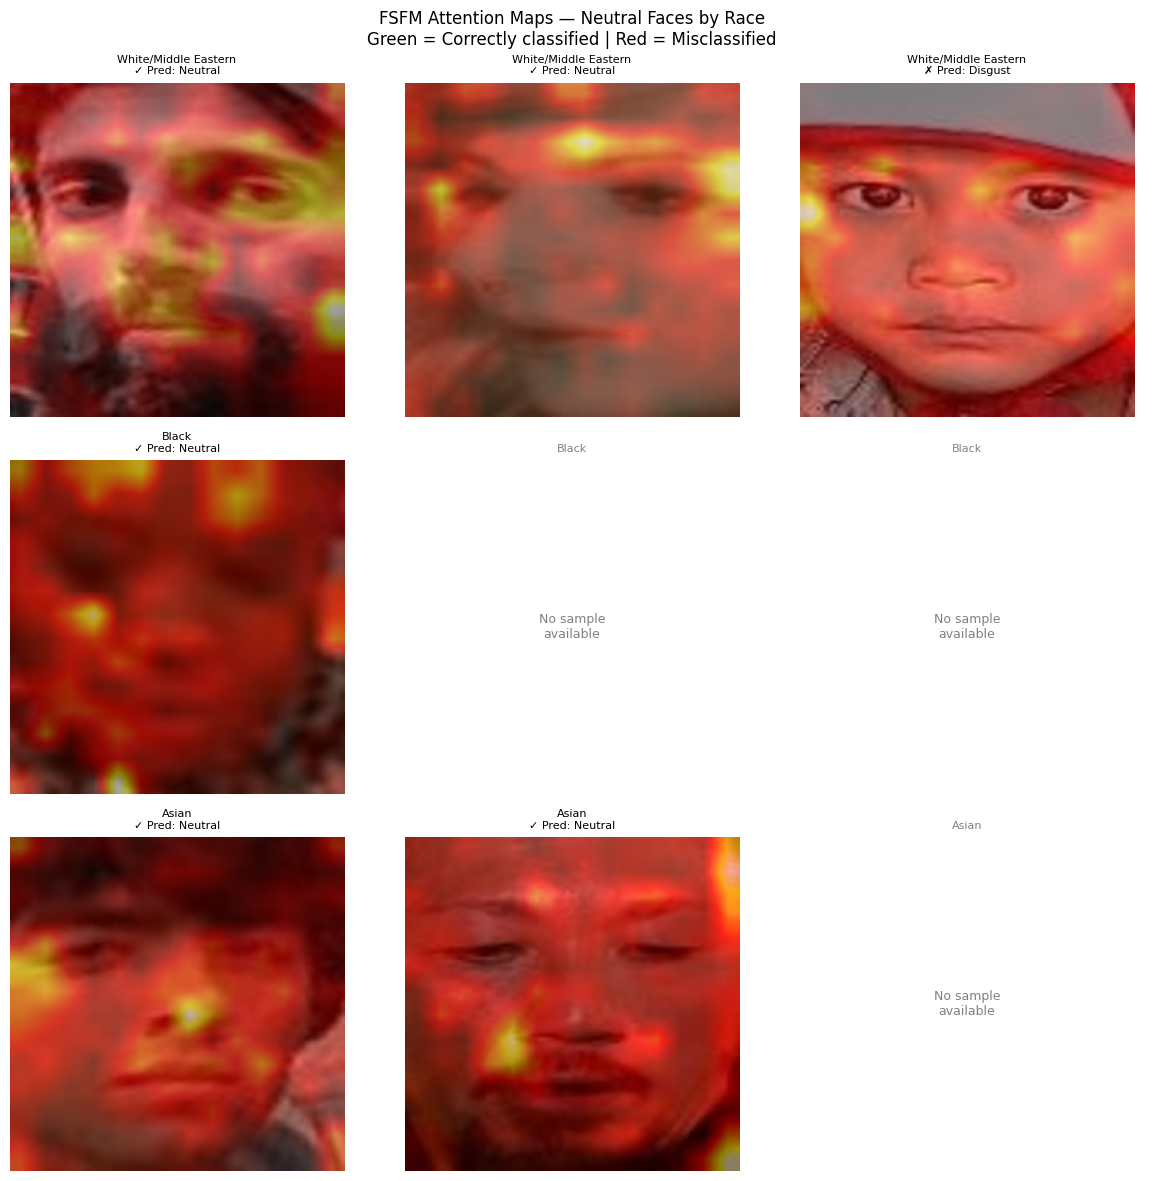

Saved.


In [10]:
def get_attention_map(backbone, img_tensor):
    backbone.eval()
    for block in backbone.blocks:
        block.attn.fused_attn = False
    attn_maps = []
    def hook_fn(module, input, output):
        attn_maps.append(output.detach().cpu())
    hooks = []
    for block in backbone.blocks:
        hooks.append(block.attn.attn_drop.register_forward_hook(hook_fn))
    with torch.no_grad():
        _ = backbone.forward_features(img_tensor.unsqueeze(0).cuda())
    for h in hooks:
        h.remove()
    for block in backbone.blocks:
        block.attn.fused_attn = True
    last_attn = attn_maps[-1]
    cls_attn  = last_attn[0, :, 0, 1:].mean(0).reshape(14, 14)
    return cls_attn

# Regenerate figure with clean empty panels
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row, race_id in enumerate([0, 1, 2]):
    race_name = RACE_NAMES[race_id]
    correct   = selected[race_id]['correct']
    wrong     = selected[race_id]['wrong']

    slots = []
    slots.append(('correct', correct[0]) if len(correct) >= 1 else None)
    slots.append(('correct', correct[1]) if len(correct) >= 2 else None)
    slots.append(('wrong',   wrong[0])   if len(wrong)   >= 1 else None)

    for col, slot in enumerate(slots):
        ax = axes[row][col]
        ax.axis('off')
        if slot is None:
            ax.set_facecolor('#f5f5f5')
            ax.text(0.5, 0.5, 'No sample\navailable',
                    ha='center', va='center', fontsize=9,
                    color='gray', transform=ax.transAxes)
            ax.set_title(f"{race_name}", fontsize=8, color='gray')
            continue

        outcome, result = slot
        idx, pred, true, race = result
        img_tensor, label, race_val, gender, age = test_ds[idx]
        img_path = test_ds.samples[idx][0]
        pil_img  = Image.open(img_path).convert('RGB')
        attn_map = get_attention_map(backbone, img_tensor)
        pred_name = RAFDB_CLASSES[pred]
        symbol    = '✓' if outcome == 'correct' else '✗'
        title     = f"{race_name}\n{symbol} Pred: {pred_name}"
        visualize_attention(img_tensor, attn_map, pil_img, title, ax)
        color = 'green' if outcome == 'correct' else 'red'
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(3)
            spine.set_edgecolor(color)

plt.suptitle(
    "FSFM Attention Maps — Neutral Faces by Race\n"
    "Green = Correctly classified | Red = Misclassified",
    fontsize=12
)
plt.tight_layout()
plt.savefig(f'{RAFDB_CACHE}/attention_maps_neutral_clean.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

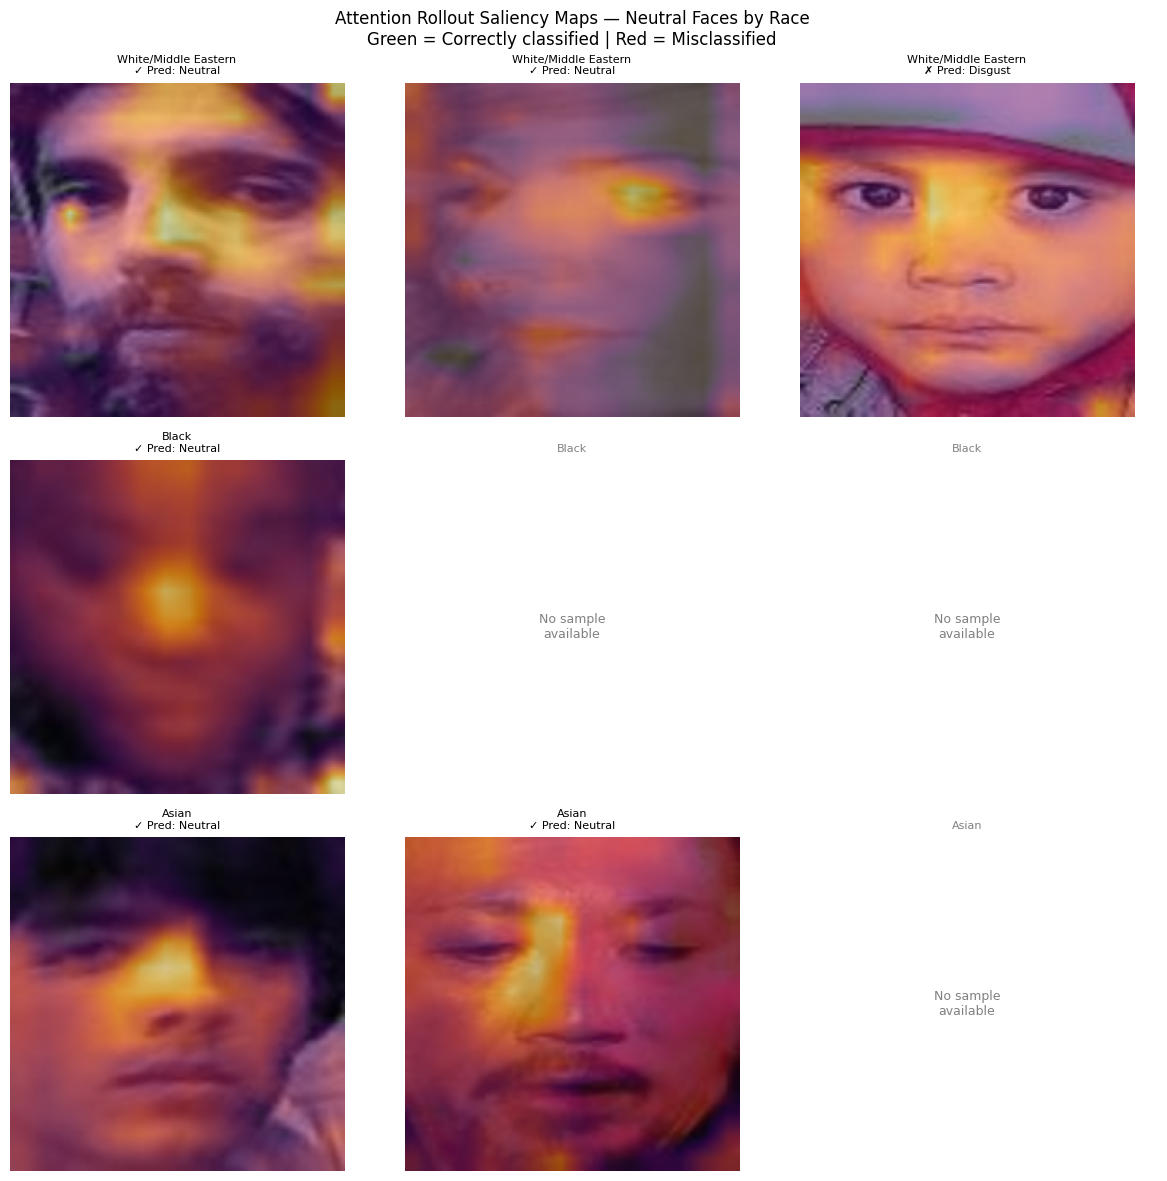

Saved.


In [16]:
def get_attention_rollout(backbone, img_tensor):
    """
    Attention rollout: aggregates attention across all layers.
    More reliable than GradCAM for ViT.
    """
    backbone.eval()
    for block in backbone.blocks:
        block.attn.fused_attn = False

    attn_maps = []
    def hook_fn(module, input, output):
        attn_maps.append(output.detach().cpu())

    hooks = []
    for block in backbone.blocks:
        hooks.append(block.attn.attn_drop.register_forward_hook(hook_fn))

    with torch.no_grad():
        _ = backbone.forward_features(img_tensor.unsqueeze(0).cuda())

    for h in hooks:
        h.remove()
    for block in backbone.blocks:
        block.attn.fused_attn = True

    # Attention rollout: multiply attention matrices across layers
    # Each attn_map: (1, heads, 197, 197)
    rollout = torch.eye(197)
    for attn in attn_maps:
        # Average over heads
        attn_avg = attn[0].mean(0)  # (197, 197)
        # Add residual connection
        attn_avg = attn_avg + torch.eye(197)
        attn_avg = attn_avg / attn_avg.sum(dim=-1, keepdim=True)
        rollout = torch.matmul(attn_avg, rollout)

    # CLS token attention to patches
    cls_attn = rollout[0, 1:]      # (196,)
    cls_attn = cls_attn.reshape(14, 14)
    cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)
    return cls_attn


def plot_saliency(img_tensor, cam, pil_img, title, ax):
    cam_up = F.interpolate(
        cam.unsqueeze(0).unsqueeze(0),
        size=(224, 224), mode='bilinear', align_corners=False
    ).squeeze().numpy()

    img_np = np.array(pil_img.resize((224, 224)))
    ax.imshow(img_np)
    ax.imshow(cam_up, cmap='inferno', alpha=0.55)
    ax.set_title(title, fontsize=8)
    ax.axis('off')


# Regenerate figure with rollout
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row, race_id in enumerate([0, 1, 2]):
    race_name = RACE_NAMES[race_id]
    correct   = selected[race_id]['correct']
    wrong     = selected[race_id]['wrong']

    slots = []
    slots.append(('correct', correct[0]) if len(correct) >= 1 else None)
    slots.append(('correct', correct[1]) if len(correct) >= 2 else None)
    slots.append(('wrong',   wrong[0])   if len(wrong)   >= 1 else None)

    for col, slot in enumerate(slots):
        ax = axes[row][col]
        ax.axis('off')

        if slot is None:
            ax.set_facecolor('#f5f5f5')
            ax.text(0.5, 0.5, 'No sample\navailable',
                    ha='center', va='center', fontsize=9,
                    color='gray', transform=ax.transAxes)
            ax.set_title(f"{race_name}", fontsize=8, color='gray')
            continue

        outcome, result = slot
        idx, pred, true, race = result
        img_tensor, label, race_val, gender, age = test_ds[idx]
        img_path = test_ds.samples[idx][0]
        pil_img  = Image.open(img_path).convert('RGB')

        cam = get_attention_rollout(backbone, img_tensor)

        symbol    = '✓' if outcome == 'correct' else '✗'
        pred_name = RAFDB_CLASSES[pred]
        title     = f"{race_name}\n{symbol} Pred: {pred_name}"

        plot_saliency(img_tensor, cam, pil_img, title, ax)

        color = 'green' if outcome == 'correct' else 'red'
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(3)
            spine.set_edgecolor(color)

plt.suptitle(
    "Attention Rollout Saliency Maps — Neutral Faces by Race\n"
    "Green = Correctly classified | Red = Misclassified",
    fontsize=12
)
plt.tight_layout()
plt.savefig(f'{RAFDB_CACHE}/saliency_rollout_neutral.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [12]:
def plot_saliency(img_tensor, cam, pil_img, title, ax):
    cam_up = F.interpolate(
        cam.unsqueeze(0).unsqueeze(0),
        size=(224, 224), mode='bilinear', align_corners=False
    ).squeeze().numpy()

    # Boost contrast — stretch to full range more aggressively
    p_low, p_high = np.percentile(cam_up, [10, 90])
    cam_up = np.clip((cam_up - p_low) / (p_high - p_low + 1e-8), 0, 1)

    img_np = np.array(pil_img.resize((224, 224)))
    ax.imshow(img_np)
    ax.imshow(cam_up, cmap='inferno', alpha=0.6)  # inferno shows low values better
    ax.set_title(title, fontsize=8)
    ax.axis('off')